In [1]:
import numpy as np 
import matplotlib.pyplot as plt

# Introduction to numerical methods

János Török

# Class 6: Integration

## Rimanns Integral

<img src="class06/Riemann_sum_convergence.png" width="400px">
The simplest method for approximating integrals is by summing the area of rectangles that are defined for each subinterval. The width of the rectangle is $x_{i+1} - x_i = h$, and the height is defined by a function value $f(x)$ for some $x$ in the subinterval. An obvious choice for the height is the function value at the left endpoint, $x_i$, or the right endpoint, $x_{i+1}$, because these values can be used even if the function itself is not known. This method gives the **Riemann Integral** approximation, which is

$$\int_a^b f(x) dx \approx \sum_{i = 0}^{n-1} hf(x_i),$$

or

$$\int_a^b f(x) dx \approx \sum_{i = 1}^{n} hf(x_i),$$

depending on whether the left or right endpoint is chosen.

As with numerical differentiation, we want to characterize how the accuracy improves as $h$ gets small. To determine this characterizing, we first rewrite the integral of $f(x)$ over an arbitrary subinterval in terms of the Taylor series. The Taylor series of $f(x)$ around $a = x_i$ is

$$f(x) = f(x_i) + f^{\prime}(x_i)(x-x_i) + \cdots$$

Thus

$$\int_{x_i}^{x_{i+1}} f(x) dx = \int_{x_i}^{x_{i+1}} (f(x_i) + f^{\prime}(x_i)(x-x_i) + \cdots)\ dx$$

by substitution of the Taylor series for the function. Since the integral distributes, we can rearrange the right side into the following form:

$$\int_{x_i}^{x_{i+1}} f(x_i) dx + \int_{x_i}^{x_{i+1}} f^{\prime}(x_i)(x-x_i)dx + \cdots.\$$

Solving each integral separately results in the approximation

$$\int_{x_i}^{x_{i+1}} f(x) dx = hf(x_i) + \frac{h^2}{2}f^{\prime}(x_i) + O(h^3),$$

which is just

$$\int_{x_i}^{x_{i+1}} f(x) dx = hf(x_i) + O(h^2).$$

Since the $hf(x_i)$ term is our Riemann integral approximation for a single subinterval, the Riemann integral approximation over a single interval is $O(h^2)$.

If we sum the $O(h^2)$ error over the entire Riemann sum, we get $nO(h^2)$. The relationship between $n$ and $h$ is

$$h = \frac{b - a}{n},$$

and so our total error becomes $\frac{b - a}{h}O(h^2) = O(h)$ over the whole interval. Thus the overall accuracy is $O(h)$.

The **Midpoint Rule** takes the rectangle height of the rectangle at each subinterval to be the function value at the midpoint between $x_i$ and $x_{i+1}$, which for compactness we denote by $y_i = \frac{x_{i+1} + x_i}{2}$. The Midpoint Rule says

$$\int_a^b f(x)dx \approx \sum_{i = 0}^{n-1} hf(y_i).$$

Similarly to the Riemann integral, we take the Taylor series of $f(x)$ around $y_i$, which is

$$f(x) = f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots$$

Then the integral over a subinterval is

$$\int_{x_i}^{x_{i+1}} f(x) dx= \int_{x_i}^{x_{i+1}} \left(f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots\right) dx,$$

which distributes to

$$\int_{x_i}^{x_{i+1}} f(x) dx= \int_{x_i}^{x_{i+1}} f(y_i)dx + \int_{x_i}^{x_{i+1}} f^{\prime}(y_i)(x - y_i)dx + \int_{x_i}^{x_{i+1}} \frac{f''(y_i)(x - y_i)^2}{2!}dx + \cdots.$$


Recognizing that since $x_i$ and $x_{i+1}$ are symmetric around $y_i$, then $\int_{x_i}^{x_{i+1}} f^{\prime}(y_i)(x - y_i)dx = 0$. This is true for the integral of $(x - y_i)^p$ for any odd $p$. For the integral of $(x - y_i)^p$ and with $p$ even, it suffices to say that $\int_{x_i}^{x_{i+1}} (x - y_i)^p dx = \int_{-\frac{h}{2}}^{\frac{h}{2}} x^p dx$, which will result in some multiple of $h^{p+1}$ with no lower order powers of $h$.


Utilizing these facts reduces the expression for the integral of $f(x)$ to

$$\int_{x_i}^{x_{i+1}} f(x) dx= hf(y_i) + O(h^3).$$

Since $hf(y_i)$ is the approximation of the integral over the subinterval, the Midpoint Rule is $O(h^3)$ for one subinterval, and using similar arguments as for the Riemann Integral, is $O(h^2)$ over the whole interval. Since the Midpoint Rule requires the same number of calculations as the Riemann Integral, we essentially get an extra order of accuracy for free! However, if $f(x_i)$ is given in the form of data points, then we will not be able to compute $f(y_i)$ for this integration scheme.

In [2]:
def Riemann_L(f,a,b,h):
    x = np.arange(a, b, h)
    I = (f(x) * h).sum()
    return I

In [3]:
Riemann_L(np.sin,0,np.pi,0.3)

1.996213118588117

In [6]:
def Riemann_C(f,a,b,h):
    x = np.arange(a, b, h)
    I = (f(x+h/2) * h).sum()
    return I

In [5]:
Riemann_C(np.sin,0,np.pi,0.3)

1.9949524298224084

## Higher dimensions
$$I =\int_{a}^{b}dx\int_{x_1}^{x_2}dy f(x,y)$$
Example:
$$ \int_{0}^{1}dx\int_{0}^{x}xydy=\frac{1}{8}$$

In [6]:
def Riemann_2d(f,a,b,hx,fx1,fx2,hy):
    I = 0.0
    xa = np.arange(a,b,hx)
    for x in xa:
        y = np.arange(fx1(x),fx2(x),hy)
        I += (f(x+hx/2,y+hy/2) * hx * hy).sum()
    return(I)

In [7]:
def f2(x,y):
    return x*y

Riemann_2d(f2,0,1,0.01,lambda _: 0, lambda x:x,0.01)

### Let us measure the error

In [8]:
ha = np.logspace(-4,-1,100)
I_ha = np.array([Riemann_2d(f2,0,1,h,lambda _: 0, lambda x:x,h) for h in ha])

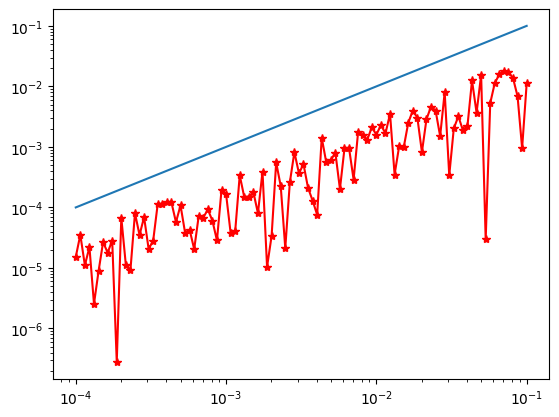

In [9]:
plt.loglog(ha,np.abs(I_ha- 0.125),"r*-")
plt.loglog(ha,ha);

## Trapezoid rule

The **Trapezoid Rule** fits a trapezoid into each subinterval and sums the areas of the trapezoid to approximate the total integral. This approximation for the integral to an arbitrary function is shown in the following figure. For each subinterval, the Trapezoid Rule computes the area of a trapezoid with corners at $(x_i, 0), (x_{i+1}, 0), (x_i, f(x_i))$, and $(x_{i+1}, f(x_{i+1}))$, which is $h\frac{f(x_i) + f(x_{i+1})}{2}$. Thus, the Trapezoid Rule approximates integrals according to the expression

$$\int_a^b f(x) dx \approx \sum_{i=0}^{n-1} h\frac{f(x_i) + f(x_{i+1})}{2}.$$

<img src="class06/21.03.1-Trapezoid_integral.png" alt="Trapezoid integral" title="Illustration of the trapezoid integral procedure. The area below the curve is approximated by a summation of trapezoids that approximate the function." width="400"/>

**TRY IT!** You may notice that the Trapezoid Rule "double-counts" most of the terms in the series. To illustrate this fact, consider the expansion of the Trapezoid Rule:

\begin{eqnarray*}\sum_{i=0}^{n-1} h\frac{f(x_i) + f(x_{i+1})}{2} &=& \frac{h}{2} \left[(f(x_0) + f(x_1)) + (f(x_1) + f(x_2)) + (f(x_2)\right. \\
&&\left. + f(x_3)) + \cdots + (f(x_{n-1}) + f(x_n))\right].\end{eqnarray*}

Computationally, this is many extra additions and calls to $f(x)$ than is really necessary. We can be more computationally efficient using the following expression.

$$\int_a^b f(x) dx \approx \frac{h}{2} \left(f(x_0) + 2 \left(\sum_{i=1}^{n-1} f(x_i)\right) + f(x_n)\right).$$

To determine the accuracy of the Trapezoid Rule approximation, we first take Taylor series expansion of $f(x)$ around $y_i = \frac{x_{i+1} + x_i}{2}$, which is the midpoint between $x_i$ and $x_{i+1}$. This Taylor series expansion is

$$f(x) = f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots$$

Computing the Taylor series at $x_i$ and $x_{i+1}$ and noting that $x_i - y_i = -\frac{h}{2}$ and $x_{i+1} - y_i = \frac{h}{2}$, results in the following expressions:

$$f(x_i) = f(y_i) - \frac{hf^{\prime}(y_i)}{2} + \frac{h^2f''(y_i)}{8} - \cdots$$

and

$$f(x_{i+1}) = f(y_i) + \frac{hf^{\prime}(y_i)}{2} + \frac{h^2f''(y_i)}{8} + \cdots.$$

Taking the average of these two expressions results in the new expression,

$$\frac{f(x_{i+1})+f(x_i)}{2} = f(y_i) + O(h^2).$$

Solving this expression for $f(y_i)$ yields

$$f(y_i) = \frac{f(x_{i+1})+f(x_i)}{2} + O(h^2).$$

Now returning to the Taylor expansion for $f(x)$, the integral of $f(x)$ over a subinterval is

$$\int_{x_i}^{x_{i+1}} f(x) dx = \int_{x_i}^{x_{i+1}} \left(f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots\right) dx.$$

Distributing the integral results in the expression

$$\int_{x_i}^{x_{i+1}} f(x) dx = \int_{x_i}^{x_{i+1}} f(y_i) dx + \int_{x_i}^{x_{i+1}} f^{\prime}(y_i)(x - y_i)dx + \int_{x_i}^{x_{i+1}} \frac{f''(y_i)(x - y_i)^2}{2!} dx + \cdots$$

Now since $x_i$ and $x_{i+1}$ are symmetric around $y_i$, the integrals of the odd powers of $(x - y_i)^p$ disappear and the even powers resolve to a multiple $h^{p+1}$.

$$\int_{x_i}^{x_{i+1}} f(x) dx = hf(y_i) + O(h^3).$$

Now if we substitute $f(y_i)$ with the expression derived explicitly in terms of $f(x_i)$ and $f(x_{i+1})$, we get

$$\int_{x_i}^{x_{i+1}} f(x) dx = h \left(\frac{f(x_{i+1})+f(x_i)}{2} + O(h^2)\right) + O(h^3), $$

which is equivalent to

$$h \left(\frac{f(x_{i+1})+f(x_i)}{2}\right) + hO(h^2) + O(h^3)$$

and therefore,

$$\int_{x_i}^{x_{i+1}} f(x) dx = h \left(\frac{f(x_{i+1})+f(x_i)}{2}\right) + O(h^3).$$

Since $\frac{h}{2}(f(x_{i+1}) + f(x_i))$ is the Trapezoid Rule approximation for the integral over the subinterval, it is $O(h^3)$ for a single subinterval and $O(h^2)$ over the whole interval.

In [7]:
def trapeziod(f,a,b,h):
    x = np.arange(a, b, h)
    I = ((f(x) + f(x+h)) * h).sum() / 2
    return I

In [11]:
trapeziod(np.sin,0,np.pi,0.3)


1.9725512644666299

In [12]:
ha = np.logspace(-4,-1,100)
Ra = np.array([Riemann_C(np.sin,0,np.pi,h) for h in ha])
Ta = np.array([trapeziod(np.sin,0,np.pi,h) for h in ha])

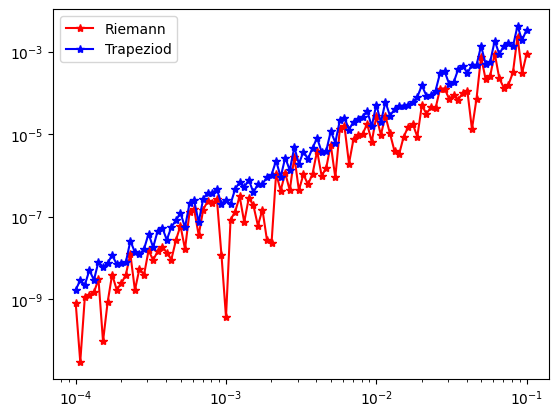

In [13]:
plt.loglog(ha,np.abs(Ra-2),"r*-",label="Riemann");
plt.loglog(ha,np.abs(Ta-2),"b*-",label="Trapeziod");
plt.legend();

In [14]:
ha = np.logspace(-1,1,100)
Ra = np.array([Riemann_C(np.exp,-100,0,h) for h in ha])
Ta = np.array([trapeziod(np.exp,-100,0,h) for h in ha])

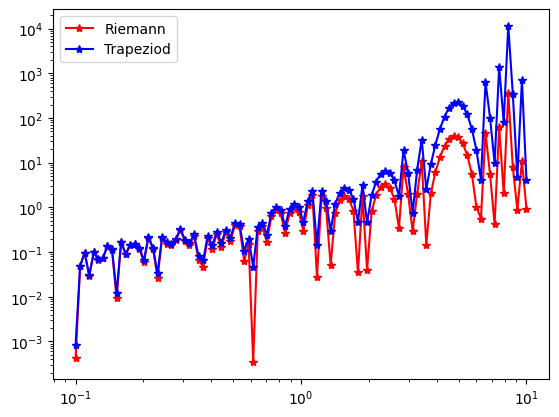

In [15]:
plt.loglog(ha,np.abs(Ra-1+np.exp(-100)),"r*-",label="Riemann");
plt.loglog(ha,np.abs(Ta-1+np.exp(-100)),"b*-",label="Trapeziod");
plt.legend();

### What is the difference?
How come that the box integral is better? 
They are actually the same, the only difference is at the boundaries!

# Simpson's Rule

Consider *two* consecutive subintervals, $[x_{i-1}, x_i]$ and $[x_i, x_{i+1}]$. **Simpson's Rule** approximates the area under $f(x)$ over these two subintervals by fitting a quadratic polynomial through the points $(x_{i-1}, f(x_{i-1})), (x_i, f(x_i))$, and $(x_{i+1}, f(x_{i+1}))$, which is a unique polynomial, and then integrating the quadratic exactly. The following shows this integral approximation for an arbitrary function.

<img src="class06/21.04.1-Simpson_integral.png" alt="Simpsons integral" title="Illustration of the Simpson integral formula. Discretization points are grouped by three, and a parabola is fit between the three points. This can be done by a typical interpolation polynomial. The area under the curve is approximated by the area under the parabola." width="350"/>

First, we construct the quadratic polynomial approximation of the function over the two subintervals. The easiest way to do this is to use Lagrange polynomials, which was discussed in [Chapter 17](chapter17.04-Lagrange-Polynomial-Interpolation.ipynb). By applying the formula for constructing Lagrange polynomials we get the polynomial

\begin{eqnarray*}P_i(x) &=& f(x_{i-1})\frac{(x - x_i)(x - x_{i+1})}{(x_{i-1} - x_i)(x_{i-1} - x_{i+1})} + f(x_i)\frac{(x - x_{i-1})(x - x_{i+1})}{(x_{i} - x_{i-1})(x_{i} - x_{i+1})}\\
&&+ f(x_{i+1})\frac{(x - x_{i-1})(x - x_{i})}{(x_{i+1} - x_{i-1})(x_{i+1} -
x_{i})},\end{eqnarray*}

and with substitutions for $h$ results in

$$P_i(x) = \frac{f(x_{i-1})}{2h^2} (x - x_i)(x - x_{i+1}) - \frac{f(x_i)}{h^2} (x - x_{i-1})(x - x_{i+1}) + \frac{f(x_{i+1})}{2h^2} (x - x_{i-1})(x - x_{i}).$$

You can confirm that the polynomial intersects the desired points. With some algebra and manipulation, the integral of $P_i(x)$ over the two subintervals is

$$\int_{x_{i-1}}^{x_{i+1}} P_i(x) dx = \frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1}).$$

To approximate the integral over $(a, b)$, we must sum the integrals of $P_i(x)$ over every *two* subintervals since $P_i(x)$ spans two subintervals. Substituting $\frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1}))$ for the integral of $P_i(x)$ and regrouping the terms for efficiency leads to the formula

$$\int_a^b f(x) dx \approx \frac{h}{3} \left[f(x_0)+4 \left(\sum_{i=1, i\  {\text{odd}}}^{n-1}f(x_i)\right)+2 \left(\sum_{i=2, i\  {\text{even}}}^{n-2}f(x_i)\right)+f(x_n)\right].$$

This regrouping is illustrated in the figure below:

<img src="class06/21.04.2-Simpson_integral_2.png" alt="Regrouping" title="Illustration of the accounting procedure to approximate the function f by the Simpson rule for the entire interval [a, b]." width="350"/>

**WARNING!** Note that to use Simpson's Rule, you **must** have an even number of intervals and, therefore, an odd number of grid points.

To compute the accuracy of the Simpson's Rule, we take the Taylor series approximation of $f(x)$ around $x_i$, which is

$$f(x) = f(x_i) + f^{\prime}(x_i)(x - x_i) + \frac{f''(x_i)(x-x_i)^2}{2!} + \frac{f'''(x_i)(x-x_i)^3}{3!} + \frac{f''''(x_i)(x-x_i)^4}{4!} + \cdots$$

Computing the Taylor series at $x_{i-1}$ and $x_{i+1}$ and substituting for $h$ where appropriate gives the expressions

$$f(x_{i-1}) = f(x_i) - hf^{\prime}(x_i) + \frac{h^2f''(x_i)}{2!} - \frac{h^3f'''(x_i)}{3!} + \frac{h^4f''''(x_i)}{4!} - \cdots$$

and

$$f(x_{i+1}) = f(x_i) + hf^{\prime}(x_i) + \frac{h''(x_i)}{2!} + \frac{h^3f'''(x_i)}{3!} + \frac{h^4f''''(x_i)}{4!} + \cdots$$

Now consider the expression $\frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6}$. Substituting the Taylor series for the respective numerator values produces the equation

$$\frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6} = f(x_i) + \frac{h^2}{6}f''(x_i) + \frac{h^4}{72}f''''(x_i) + \cdots$$

Note that the odd terms cancel out. This implies

$$f(x_i) =\frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6} - \frac{h^2}{6}f''(x_i) + O(h^4).$$

By substitution of the Taylor series for $f(x)$, the integral of $f(x)$ over two subintervals is then

\begin{eqnarray*}\int_{x_{i-1}}^{x_{i+1}} f(x) dx &=& \int_{x_{i-1}}^{x_{i+1}} \left(f(x_i) + f^{\prime}(x_i)(x - x_i) + \frac{f''(x_i)(x-x_i)^2}{2!}\right.\\
&&\qquad\qquad\left. + \frac{f'''(x_i)(x-x_i)^3}{3!}+ \frac{f''''(x_i)(x-x_i)^4}{4!} + \cdots\right)
dx.\end{eqnarray*}

Again, we distribute the integral and without showing it, we drop the integrals of terms with odd powers because they are zero.

$$\int_{x_{i-1}}^{x_{i+1}} f(x) dx = \int_{x_{i-1}}^{x_{i+1}} f(x_i) dx + \int_{x_{i-1}}^{x_{i+1}}\frac{f''(x_i)(x-x_i)^2}{2!}dx + \int_{x_{i-1}}^{x_{i+1}}\frac{f''''(x_i)(x-x_i)^4}{4!}dx + \cdots.$$

We then carry out the integrations. As will soon be clear, it benefits us to compute the integral of the second term exactly. The resulting equation is

$$\int_{x_{i-1}}^{x_{i+1}} f(x) dx = 2h f(x_i) + \frac{h^3}{3}f''(x_i) + O(h^5).$$

Substituting the expression for $f(x_i)$ derived earlier, the right-hand side becomes

$$2h \left(\frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6} - \frac{h^2}{6}f''(x_i) + O(h^4)\right) + \frac{h^3}{3}f''(x_i) + O(h^5),$$

which can be rearranged to

$$\left[\frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1})) - \frac{h^3}{3}f''(x_i) + O(h^5)\right] + \frac{h^3}{3}f''(x_i) + O(h^5).$$

Canceling and combining the appropriate terms results in the integral expression

$$\int_{x_{i-1}}^{x_{i+1}} f(x) dx = \frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1})) + O(h^5).$$

Recognizing that $\frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1}))$ is exactly the Simpson's Rule approximation for the integral over this subinterval, this equation implies that Simpson's Rule is $O(h^5)$ over a subinterval and $O(h^4)$ over the whole interval. Because the $h^3$ terms cancel out exactly, Simpson's Rule gains another *two* orders of accuracy!

In [11]:
def Simpson(f,a,b,h):
    x = np.arange(a, b, h)
    I = ((f(x-h) + 4 * f(x) + f(x+h)) * h).sum() / 6
    return I

In [12]:
ha = np.logspace(-4,-1,100)
Ra = np.array([Riemann_C(np.sin,0,np.pi,h) for h in ha])
Ta = np.array([trapeziod(np.sin,0,np.pi,h) for h in ha])
Sa = np.array([Simpson(np.sin,0,np.pi,h) for h in ha])

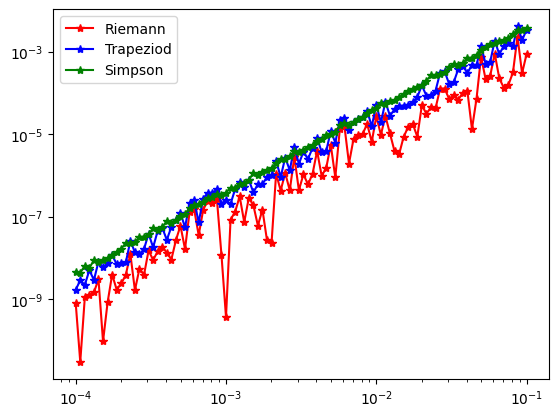

In [13]:
plt.loglog(ha,np.abs(Ra-2),"r*-",label="Riemann");
plt.loglog(ha,np.abs(Ta-2),"b*-",label="Trapeziod");
plt.loglog(ha,np.abs(Sa-2),"g*-",label="Simpson");
plt.legend();

## Conclusion
All these methods differ only in the handling of the boundaries, therefore they are essentially the same. The boundary seems to effect the stability of the results. Generally scaling down effect of the boundaries is a good idea.

# Gauss–Legendre quadrature


It turns out that it is important where we take the points. Let us optimize it! For simplicity we take all integrals to be between $-1$ and $1$. The <b>Gauss-Legendre quadrature</b> states that:
$$\int_{-1}^1 f(x)\,dx \approx \sum_{i=1}^n w_i f(x_i)$$

where

* $n$ is the number of sample points used,
* $w_i$ are quadrature weights, and
* $x_i$ are the roots of the $n$th <b>Legendre polynomial</b>.

If we want $n$ sample points, then the above formula can be made exact for polinomials up to degree $2n-1$. Since in a polynomial of degree $2n-1$ there are $2n$ coefficients (do not forget the constant term!), and it will give us $2n$ equations for the weights $w_i$ and positions $x_i$.

### Example with polynimial of degree 1
A single sample at $x_0$ and a weight $w_0$ is enough to calculate the integral of a degree one ploynomial:
$$f(x) = A*x+B$$
Consider the integral between $[-1,1]$
$$\int_{-1}^1 f(x) dx = w_0f(x_0)$$
Substituting in the form of $f(x)$:
$$
\begin{align*}
\int_{-1}^1(Ax+B)dx&=w_0(Ax_0+B)\cr
\left[\frac{A}{2}x^2+Bx\right]_{-1}^1&=w_0(Ax_0+B)\cr
2B&=Aw_0x_0+w_0B\cr
B(2-w_0)&=Aw_0x_0
\end{align*}
$$
This should be true for any polynomial, i.e. for any pair of $A$ and $B$. So it gives us two equations for our two unknowns
$$
\begin{align*}
x_0w_0&=0\cr
w_0&=2
\end{align*}
$$
Thus $x_0=0$ and $w_0=2$. One may say that this is cheating as we are integrating a constant plus an odd function for a symmetric interval.
Let us the move to measuring two poits:
$$ \int_{-1}^1 f(x) dx = w_0f(x_0)+w_1f(x_1)$$
We have four unknowns $ w_0,~x_0,~w_1,~x_1$ so it will be exact for degree 3 polynomials:
$$f(x) = Ax^3+Bx^2+Cx+D$$
Let us perform the integral with this polynomial:
$$
\begin{align*}
\int_{-1}^1(Ax^2+Bx^2+Cx+D)dx&=w_0(Ax_0^3+Bx_0^2+Cx_0+D)+w_1(Ax_1^3+Bx_1^2+Cx_1+D)\cr
\left[\frac{A}{4}x^4+\frac{B}{3}x^3+\frac{C}{2}x^2+Dx\right]_{-1}^1&=
A(w_0x_0^3+w_1x_1^3) +B(w_0x_0^2+w_1x_1^2)+C(w_0x_0+w_1x_1)+D(w_0+w_1)\cr
\frac{2}{3}B+2D&=
A(w_0x_0^3+w_1x_1^3) +B(w_0x_0^2+w_1x_1^2)+C(w_0x_0+w_1x_1)+D(w_0+w_1)
\end{align*}
$$
As before this must be tru for all polynomials as the multipliers of $A$, $B$, $C$, $D$ should be zero which gives us the following four equations:
$$
\begin{align*}
w_0x_0^3+w_1x_1^3&=0\cr
w_0x_0^2+w_1x_1^2&=2/3\cr
w_0x_0+w_1x_1&=0\cr
w_0+w_1&=2
\end{align*}
$$
The solutions is:
$$
\begin{align*}
w_0=1, \qquad &w_1=1\cr
x_0=-\sqrt{1/3},\qquad&x_1=+\sqrt{1/3}
\end{align*}
$$
The solution is for the points the roots of the $n$th Legendre polynomial and the weightsare given by the formula:
$$ w_i = \frac{2}{\left( 1 - x_i^2 \right) \left[P'_n(x_i)\right]^2}.$$
<img src="class06/Gauss-Legendre.png" width=600>

In [2]:
import scipy.integrate

In [8]:
scipy.integrate.quad(np.sin,0,np.pi)

(2.0, 2.220446049250313e-14)

In [15]:
def step(x,e=0.001):
    return (np.abs(x) < e) * 1

In [16]:
scipy.integrate.quad(step,-1,1)

(0.0, 0.0)

## Unequal $x_i$ coordinates

In [25]:
N = 50
x = np.random.random(N) * np.pi
x.sort()

In [26]:
y = np.sin(x)

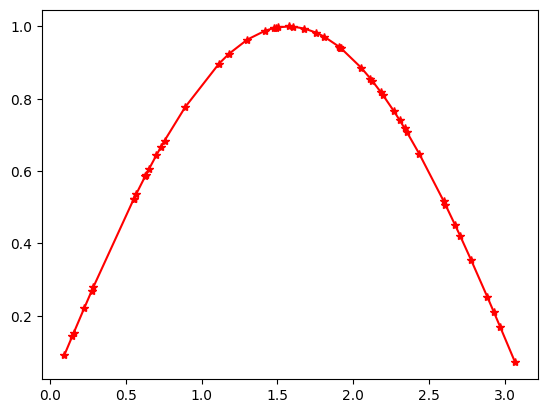

In [28]:
plt.plot(x,y,"r*-")

In [29]:
(x[1:] - x[:-1]).sum()

2.979461212869255

In [32]:
def xy_integrate_box(x,y):
    I = ((x[1:] - x[:-1]) * y[1:]).sum()
    return(I)

In [33]:
def xy_integrate_trapeze(x,y):
    I = ((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2).sum()
    return(I)

In [34]:
xy_integrate_box(x,y),xy_integrate_trapeze(x,y)

(2.0158649016273857, 1.9906735459410907)

### Error:

In [63]:
na = np.arange(5,200,10)
IB = np.zeros(len(na),dtype=float)
IT = np.zeros(len(na),dtype=float)
sample = 100
for i,N in enumerate(na):
    for _ in range(sample):
        x = np.random.random(N) * np.pi/2 + np.pi/2 
        x.sort()
        y = np.sin(x)
        IB[i] += xy_integrate_box(x,y)
        IT[i] += xy_integrate_trapeze(x,y)
IB = IB / sample
IT = IT / sample

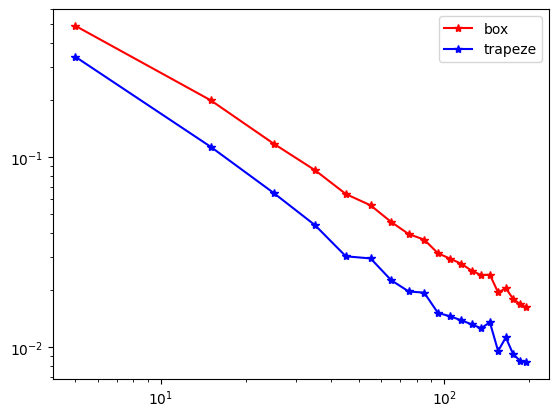

In [64]:
plt.loglog(na,np.abs(IB-1),"r*-",label="box")
plt.loglog(na,np.abs(IT-1),"b*-",label="trapeze")
plt.legend()
plt.show();

# Monte-Carlo Integration

What if the whole thing is very messy and the interval is complicated. Random sampling!

### 1d Riemans integral

In [22]:
N = 1000
x = np.random.random((N,2)) * np.array([np.pi,1])

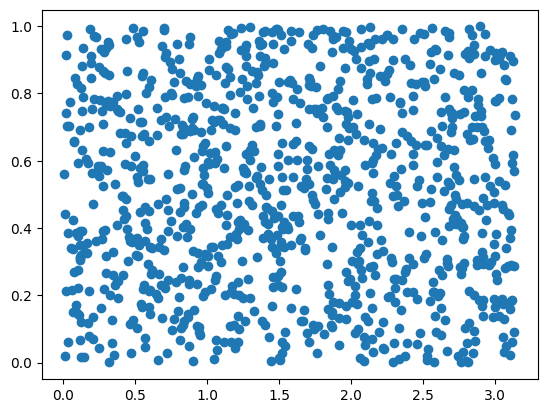

In [25]:
plt.scatter(x[:,0],x[:,1])

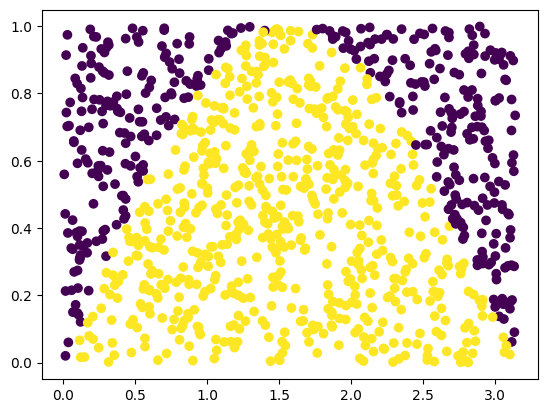

In [26]:
plt.scatter(x[:,0],x[:,1],c=x[:,1] < np.sin(x[:,0]))

### Algorithm:
 * Box the function in a rectangle
 * Generate as many points as you wish
 * Count the ones which are under the function
 * If the area of the original box is $V$ and the fraction of points under the curve is $f$, then the integral is
$$I=fV$$

In [29]:
f = (x[:,1] < np.sin(x[:,0])).sum()/N
V = np.pi * 1
I = f * V
print(I)

1.944645852572082


### Precision:

In [12]:
sample = 100
na = [100,1000,10000,100000,1000000]
I = np.zeros(len(na),dtype=float)
for i,N in enumerate(na):
    for _ in range(sample):
        x = np.random.random((N,2)) * np.array([np.pi,1])
        f = (x[:,1] < np.sin(x[:,0])).sum()/N
        V = np.pi * 1
        I[i] += f * V
I /= sample

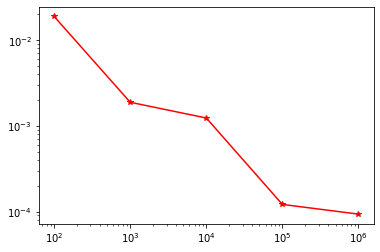

In [13]:
plt.loglog(na,np.abs(I-2),"r*-");

## More than 1 dimensions
Previous example

$$ \int_{0}^{1}dx\int_{0}^{x}xydy=\frac{1}{8}$$

In [17]:
N = 10000
x = np.random.random((N,2))
f = ((x[:,1] < x[:,0]) * x[:,1] * x[:,0]).sum()/N
V = 1.0
I = f * V
print(I)

0.12455968170639248


## Second example: Spheroid
<img src="class06/Spheroid.png" width=600px>
$$\frac{x^2+y^2}{a^2}+\frac{z^2}{c^2}=1$$
Example parameters $a=2$, $c=3$. Volume: $V=\frac{4}{3}\pi a^2c\simeq50.265$

### Volume

#### Solution #1: traditional 3d integral
$$
V = \int_{-\sqrt{a^2-y^2-a^2z^2/c^2}}^{\sqrt{a^2-y^2-a^2z^2/c^2}}dx
\int_{-\sqrt{a^2-a^2z^2/c^2}}^{\sqrt{a^2-a^2z^2/c^2}}dy
\int_{-c}^{c}dz
$$

In [32]:
a = 2.0
c = 3.0
V = 0.0
delta = 0.01
za = np.arange(-c,c,delta)
for z in za:
    limy = np.sqrt(np.abs(a*a-a*a*z*z/c/c))
    if limy < delta / 4: continue
    ya = np.arange(-limy,limy,delta)
    for y in ya:
        limx = np.sqrt(np.abs(a*a-y*y-a*a*z*z/c/c))
        if limx < delta / 4: continue
        xa = np.arange(-limx,limx,delta)
        for x in xa:
            V += delta**3

In [33]:
print(V)

50.35427396488433


#### Solution #2: cylindrical coordinates
This is too slow, we can use the fact that the system is cylindrical in the $xy$ coordinates.
$$
V = \int_{-c}^c dz \int_0^{\sqrt{a^2-a^2z^2/c^2}} dr \int_0^{2\pi}r d\varphi
$$

In [36]:
a = 2.0
c = 3.0
V = 0.0
delta = 0.01
za = np.arange(-c,c,delta)
for z in za:
    limr = np.sqrt(np.abs(a*a-a*a*z*z/c/c))
    if limr < delta / 2: continue
    ra = np.arange(0, limr,delta)
    for r in ra:
        V += r * delta**2 * 2 * np.pi

In [37]:
print(V)

50.23980936223119


#### Solution #3: Monte-Carlo in 3d
This is useful if the formula are difficult to get, since here we can use the original equation:

In [45]:
N = 1000000
x = (np.random.random((N,3))*2 - 1.0) * np.array([a,a,c])
#define x^2
x2 = x*x
f = ((x2[:,0]+x2[:,1])/a/a + x2[:,2]/c/c <= 1.0).sum()/N
V = a*a*c*8
I = f * V
print(I)

50.261088


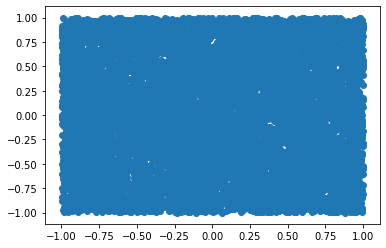

In [42]:
plt.scatter(x[:,0],x[:,2])

#### Solution #4: Monte-Carlo in 2d
Correction is needed for the radius, we multiply the result with $r\pi$, the reason for dropping the 2 is that it is incorporated in $r\in[-a,a]$. 

In [50]:
N = 100000
x = (np.random.random((N,2))*2 - 1.0) * np.array([a,c])
#define x^2
x2 = x*x
f = (((x2[:,0])/a/a + x2[:,1]/c/c <= 1.0)*np.sqrt(x2[:,0])).sum()/N * np.pi
V = a*c*4
I = f * V
print(I)

50.28105421598887


#### Solution #5: Monte-Carlo 2d, with non-uniform random numbers
We need random numbers the probability distribution of which is a straight line

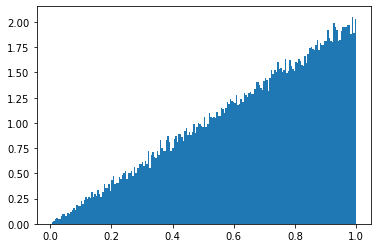

In [52]:
h = plt.hist(np.random.triangular(0, 1, 1, 100000), bins=200,
             density=True)

In [59]:
N = 1000000
r = np.random.triangular(0, a, a, N)
z = (np.random.random(N)*2 - 1) *c
f = (r*r/a/a + z*z/c/c <= 1.0).sum()/N
V = a*a*c * np.pi * 2
I = f * V
print(I)

50.259928121625144
